# Understanding the Eklipse Creator Journey

## Engagement, Content Interaction, and Monetization Analysis

### Objective

1. This analysis explores creator behavior, platform engagement, content interaction, and monetization trends within the Eklipse platform

2. The goal is to identify business metrics that can help support:
- platform growth
- creator retention
- creator satisfaction
- monetization strategy
- product optimization

3. The analysis combines:
- SQL based metric extraction
- Python based visualization
- business interpretation
- strategic recommendations



---



### install & import libraries

In [ ]:
!pip install duckdb -q

import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import zipfile
import os

from IPython.display import display



---



### visual style configuration

In [ ]:
plt.style.use('default')

PINK = '#ff69b4'
LIGHT_PINK = '#ffc0cb'

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10



---



# Uploading the Dataset

The provided dataset is uploaded as a ZIP file containing multiple CSV tables representing different user interactions inside the Eklipse platform

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving da_test_v2.zip to da_test_v2.zip




---



# Preparing the Working Environment

The ZIP dataset is extracted into a local directory to allow SQL based querying using DuckDB

In [ ]:
zip_path = '/content/da_test_v2.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['da_test_v2', '__MACOSX']




---



# Validating Extracted Files

The extracted folder structure is checked
to ensure all datasets are available correctly

In [ ]:
for root, dirs, files in os.walk('/content/data'):
    print(root)
    print(files)

/content/data
[]
/content/data/da_test_v2
['downloaded_clips.csv', 'premium.csv', 'shared_clips.csv', 'gamesession.csv', 'clips.csv']
/content/data/__MACOSX
[]
/content/data/__MACOSX/da_test_v2
['._shared_clips.csv', '._clips.csv', '._downloaded_clips.csv', '._premium.csv', '._gamesession.csv']




---



# Connectiong to DuckDB

DuckDB is used to execute SQL queries to be executed directly on CSV files efficiently without requiring a separate database server

In [ ]:
con = duckdb.connect()

BASE_PATH = '/content/data/da_test_v2'



---



# Understanding the Dataset Structure

The provided datasets represent multiple stages of the Eklipse creator ecosystem


Each dataset captures different creator interactions:

- gamesession: user submitted gameplay streams/videos

- clips: AI generated or edited clips

- downloaded_clips: clips downloaded by creators

- shared_clips: clips distributed to external platforms

- premium: premium subscription activity


These datasets allow the analysis to track:
- engagement
- creator behavior
- content value
- social distribution
- monetization



---



# Platform Data Landscape

This section evaluates the scale and structure of each dataset before analysis begins

In [ ]:
tables = [
    'clips.csv',
    'gamesession.csv',
    'downloaded_clips.csv',
    'shared_clips.csv',
    'premium.csv'
]

dataset_summary = []

for table in tables:

    query = f"""
    SELECT *
    FROM '{BASE_PATH}/{table}'
    """

    df = con.execute(query).df()

    dataset_summary.append({
        'dataset': table,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'missing_values': df.isnull().sum().sum()
    })

summary_df = pd.DataFrame(dataset_summary)

summary_df

,dataset,rows,columns,missing_values
0,clips.csv,552031,9,47246
1,gamesession.csv,37579,7,29
2,downloaded_clips.csv,12938,8,4019
3,shared_clips.csv,5798,8,5037
4,premium.csv,384,7,259




---



## Dataset Interpretation

The platform activity is heavily dominated by clip generation activity

Key observations:

- clips.csv contains more than 552K records, showing that content generation is the platform’s largest operational activity

- gamesession activity is significantly smaller, meaning a single gamesession may generate multiple clips

- sharing and downloading activities are smaller subsets, indicating that not every generated clip is distributed externally

- premium data contains relatively few records, suggesting premium conversion is still limited compared to overall platform activity



---



# Exploring the Raw Platform Data

This section previews sample records from each dataset to better understand:
- column structures
- timestamp usage
- user relationships
- content flow

In [ ]:
for table in tables:

    total_rows_query = f"""
    SELECT COUNT(*) AS total_rows
    FROM '{BASE_PATH}/{table}'
    """

    total_rows = con.execute(total_rows_query).df()

    sample_query = f"""
    SELECT *
    FROM '{BASE_PATH}/{table}'
    LIMIT 5
    """

    sample_data = con.execute(sample_query).df()

    print(f"\nDataset: {table}")
    print("-" * 60)

    print("Total Rows")
    display(total_rows)

    print("Columns")
    print(list(sample_data.columns))

    print("\nSample Data")
    display(sample_data)


Dataset: clips.csv
------------------------------------------------------------
Total Rows


,total_rows
0,552031


Columns
['id', 'user_id', 'gamesession_Id', 'clip_type_id', 'duration', 'event_name', 'game_name', 'created_at', 'join_at']

Sample Data


,id,user_id,gamesession_Id,clip_type_id,duration,event_name,game_name,created_at,join_at
0,134469944895,3095890,103039886.0,5,60,High Comment,Other Games,2023-06-01 12:00:21,2023-01-29 15:16:25
1,134470123490,3095890,103039886.0,5,60,High Comment,Other Games,2023-06-01 12:00:45,2023-01-29 15:16:25
2,134470573860,2844164,100738061.0,2,10,None,World of Warcraft,2023-06-01 12:01:47,2023-03-10 23:27:14
3,134470643745,3928914,103014694.0,1,14,Single kill,COD: Warzone3-2 & MW3-2,2023-06-01 12:01:59,2023-04-19 18:26:19
4,134470837870,3928914,103014694.0,1,14,Single kill,COD: Warzone3-2 & MW3-2,2023-06-01 12:02:30,2023-04-19 18:26:19



Dataset: gamesession.csv
------------------------------------------------------------
Total Rows


...

,user_id,clip_id,gamesession_Id,game_name,event_name,created_at,scheduled_at,join_at
0,1377027,134463197110,101121252.0,Apex Legends,None,2023-06-01 17:26:19,2023-06-01 22:30:00,2023-04-23 22:47:48
1,1377027,134463197110,101121252.0,Apex Legends,None,2023-06-01 17:27:11,2023-06-01 22:30:00,2023-04-23 22:47:48
2,4727411,133758065225,101171965.0,Other Games,None,2023-06-01 19:50:27,2023-06-01 19:50:27,2023-03-18 12:32:25
3,4727411,133758065225,101171965.0,Other Games,None,2023-06-01 19:50:28,2023-06-01 19:50:28,2023-03-18 12:32:25
4,4727411,133924026570,101171965.0,Other Games,None,2023-06-01 19:51:36,2023-06-01 19:51:36,2023-03-18 12:32:25



Dataset: premium.csv
------------------------------------------------------------
Total Rows


,total_rows
0,384


Columns
['user_id', 'starts_at', 'ends_at', 'created_at', 'updated_at', 'canceled_at', 'join_at']

Sample Data


,user_id,starts_at,ends_at,created_at,updated_at,canceled_at,join_at
0,3119140,2023-01-02,2023-03-03,2023-01-03 02:12:37,2023-03-04 00:00:18,2023-02-09,2023-10-10 05:49:30
1,2921015,2023-01-04,2023-02-04,2023-01-04 07:02:52,2023-02-05 00:00:16,2023-01-09,2023-03-31 00:17:45
2,4501997,2023-01-10,2023-05-11,2023-01-11 03:11:23,2023-05-12 00:00:07,NaT,2023-08-10 00:51:44
3,845586,2023-01-15,2023-02-15,2023-01-15 12:46:50,2023-02-16 00:00:17,2023-01-15,2023-04-20 10:00:47
4,4465860,2023-01-19,2023-12-20,2023-01-20 01:20:09,2023-11-21 00:00:11,NaT,2023-07-30 10:01:48




---





---



# Mapping the Creator Experience

The Eklipse creator workflow can be simplified into:

1. Users register to the platform
2. Users submit gamesessions
3. Eklipse generates clips automatically
4. Users download or share clips
5. Users may upgrade into premium subscribers  

This workflow becomes the foundation
for selecting business metrics



---



# Executive Summary

The analysis shows:
- increasing creator engagement
- growing content interaction
- improving premium adoption trends

The strongest growth appears during Q3–Q4 2023,
particularly in:
- creator activity
- sharing behavior
- premium subscriptions

AI generated clips remain the platform’s
dominant product feature



---



# Creator Engagement Momentum

## Business Objective

Measure how actively creators interact with the platform over time

## Why This Metric Matters

Monthly Active Users is one of the most important engagement metrics because it reflects:
- creator retention
- recurring platform usage
- ecosystem growth

## SQL Strategy Used

This query combines multiple creator activities using:
- UNION ALL
- COUNT DISTINCT

UNION ALL is used to merge:
- gamesession submissions
- clip generation
- downloads
- sharing activity

This creates a broader definition of “active users” instead of relying on only one interaction type.

COUNT DISTINCT is applied to prevent duplicated users across multiple activities

In [ ]:
query1 = f'''
SELECT
    DATE_TRUNC('month', activity.activity_date) AS month,
    COUNT(DISTINCT activity.user_id) AS monthly_active_users
FROM (

    SELECT
        user_id,
        submited_date AS activity_date
    FROM '{BASE_PATH}/gamesession.csv'
    WHERE submited_date IS NOT NULL

    UNION ALL

    SELECT
        user_id,
        created_at AS activity_date
    FROM '{BASE_PATH}/clips.csv'
    WHERE created_at IS NOT NULL

    UNION ALL

    SELECT
        user_id AS user_id,
        created_at AS activity_date
    FROM '{BASE_PATH}/downloaded_clips.csv'
    WHERE created_at IS NOT NULL

    UNION ALL

    SELECT
        user_id,
        created_at AS activity_date
    FROM '{BASE_PATH}/shared_clips.csv'
    WHERE created_at IS NOT NULL

) AS activity
GROUP BY month
ORDER BY month;
'''

result1 = con.execute(query1).df()
result1

,month,monthly_active_users
0,2023-06-01,1103
1,2023-07-01,988
2,2023-08-01,1074
3,2023-09-01,1220
4,2023-10-01,1332
5,2023-11-01,1228
6,2023-12-01,1182


### monthly active users visualization

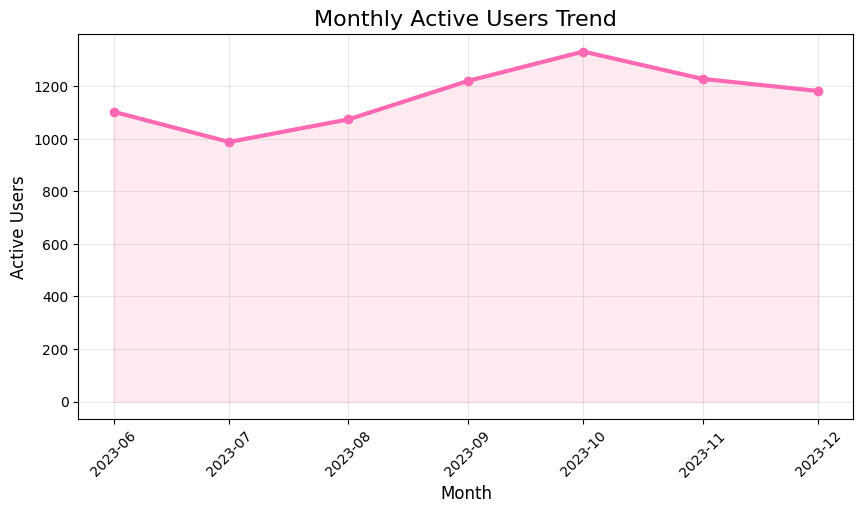

In [ ]:
result1['month'] = pd.to_datetime(result1['month'])

plt.figure(figsize=(10,5))

plt.plot(
    result1['month'],
    result1['monthly_active_users'],
    marker='o',
    color=PINK,
    linewidth=3
)

plt.fill_between(
    result1['month'],
    result1['monthly_active_users'],
    color=LIGHT_PINK,
    alpha=0.3
)

plt.title('Monthly Active Users Trend')
plt.xlabel('Month')
plt.ylabel('Active Users')

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## Insight

Monthly active users increased steadily between June and October 2023

This suggests:
- stronger creator retention
- higher recurring platform usage
- increasing creator adoption

The growth pattern indicates that creators continued returning to the platform after their initial interaction



---



# Strategic Implication

Because creator engagement continues increasing, Eklipse should prioritize:
- creator retention
- onboarding optimization
- creator personalization features

Improving creator stickiness is likely to increase:
- content generation
- sharing activity
- premium conversion potential

# Content Creation Activity

## Business Objective

Measure how many gamesessions successfully generated clips over time

## Why This Metric Matters

This metric reflects:
- creator activity
- platform usage trends
- AI clipping pipeline performance

A higher gamesession volume indicates that more creators are actively using the Eklipse platform to generate content

## SQL Strategy Used

This query uses INNER JOIN between:
- gamesession
- clips

The JOIN ensures that only gamesessions which successfully generated clips are included in the analysis

DATE_TRUNC is used to aggregate activity monthly, making trend analysis easier to interpret

COUNT DISTINCT is applied to avoid duplicated gamesession records

In [ ]:
query2 = f'''
SELECT
    DATE_TRUNC('month', gs.submited_date) AS submission_month,
    COUNT(DISTINCT gs.id) AS gamesession_submitted_with_clips
FROM '{BASE_PATH}/gamesession.csv' AS gs
JOIN '{BASE_PATH}/clips.csv' AS c
    ON gs.id = c.gamesession_Id
WHERE gs.submited_date IS NOT NULL
GROUP BY submission_month
ORDER BY submission_month;
'''

result2 = con.execute(query2).df()

result2

,submission_month,gamesession_submitted_with_clips
0,2023-06-01,6021
1,2023-07-01,5474
2,2023-08-01,5324
3,2023-09-01,6111
4,2023-10-01,5794
5,2023-11-01,4778
6,2023-12-01,3066


### content creation visualization

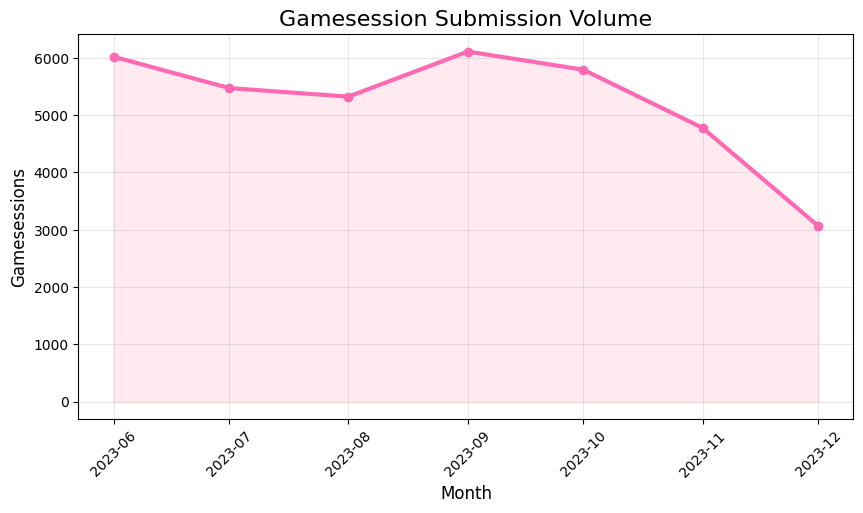

In [ ]:
result2['submission_month'] = pd.to_datetime(result2['submission_month'])

plt.figure(figsize=(10,5))

plt.plot(
    result2['submission_month'],
    result2['gamesession_submitted_with_clips'],
    marker='o',
    color=PINK,
    linewidth=3
)

plt.fill_between(
    result2['submission_month'],
    result2['gamesession_submitted_with_clips'],
    color=LIGHT_PINK,
    alpha=0.3
)

plt.title('Gamesession Submission Volume')
plt.xlabel('Month')
plt.ylabel('Gamesessions')

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## Insight

Gamesession submission activity increased steadily until September–October 2023

This indicates:
- stronger creator participation
- increasing platform activity
- growing usage of AI clipping workflows

The decline observed in December
may be influenced by incomplete monthly activity

# Strategic Implication

The increase in creator activity suggests
that creators are consistently returning
to generate content through Eklipse

To maintain this momentum, Eklipse should:
- simplify clip generation workflows
- improve AI processing speed
- encourage repeated creator activity



---



# Creator Value Realization

## Business Objective

Measure how many generated clips are downloaded by creators

## Why This Metric Matters

Download behavior reflects:
- creator satisfaction
- content usefulness
- perceived clip quality

If creators consistently download clips,it suggests that the generated content provides meaningful value.

## SQL Strategy Used

This query uses LEFT JOIN between:
- clips
- downloaded_clips

LEFT JOIN is used because not every generated clip is downloaded

Using LEFT JOIN preserves all generated clips, allowing download rate calculation
to represent the full creator population

COUNT DISTINCT prevents duplicated clip counting

In [ ]:
query3 = f'''
SELECT
    DATE_TRUNC('month', c.created_at) AS month,
    COUNT(DISTINCT c.id) AS generated_clips,
    COUNT(DISTINCT dc.clip_id) AS downloaded_clips,

    ROUND(
        COUNT(DISTINCT dc.clip_id) * 100.0
        / COUNT(DISTINCT c.id),
        2
    ) AS download_rate_percentage

FROM '{BASE_PATH}/clips.csv' c

LEFT JOIN '{BASE_PATH}/downloaded_clips.csv' dc
    ON c.id = dc.clip_id

GROUP BY month
ORDER BY month;
'''

result3 = con.execute(query3).df()

result3

,month,generated_clips,downloaded_clips,download_rate_percentage
0,2023-06-01,81789,1530,1.87
1,2023-07-01,77776,1510,1.94
2,2023-08-01,80231,1371,1.71
3,2023-09-01,87737,1913,2.18
4,2023-10-01,88862,2487,2.80
5,2023-11-01,82608,2514,3.04
6,2023-12-01,53028,1591,3.00


### download rate visualization

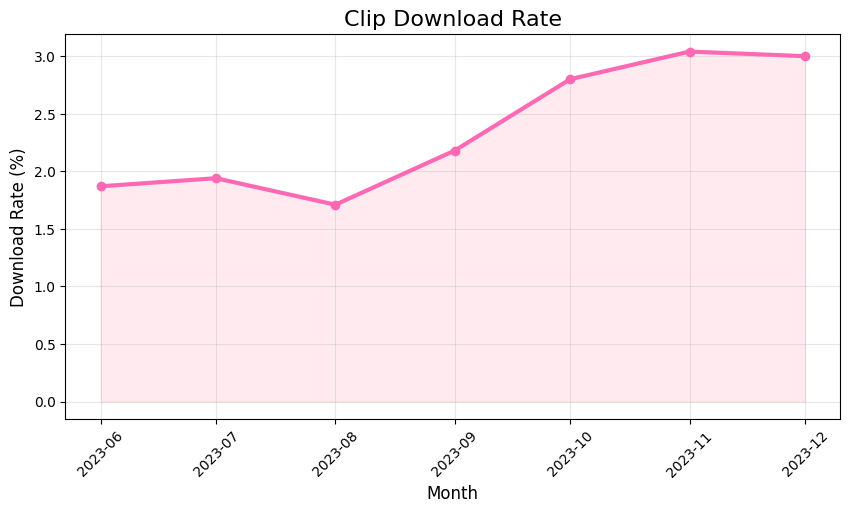

In [ ]:
result3['month'] = pd.to_datetime(result3['month'])

plt.figure(figsize=(10,5))

plt.plot(
    result3['month'],
    result3['download_rate_percentage'],
    marker='o',
    color=PINK,
    linewidth=3
)

plt.fill_between(
    result3['month'],
    result3['download_rate_percentage'],
    color=LIGHT_PINK,
    alpha=0.3
)

plt.title('Clip Download Rate')
plt.xlabel('Month')
plt.ylabel('Download Rate (%)')

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## Insight

Clip download rates improved steadily over time

This suggests:
- improving creator satisfaction
- stronger perceived content value
- better alignment between generated clips and creator expectations

The increase during Q4 2023 indicates stronger creator interaction with generated content

# Strategic Implication

Because download rates continue improving, Eklipse should continue prioritizing:
- AI clip quality improvements
- better highlight detection
- creator personalization

Improving perceived clip value is likely to increase:
- creator retention
- social sharing
- premium conversion



---



# Social Distribution Dynamics

## Business Objective

Measure how often creators share clips externally

## Why This Metric Matters

Sharing behavior reflects:
- creator engagement
- virality potential
- platform exposure

External sharing is especially important because it may contribute to:
- organic growth
- creator acquisition
- platform visibility

## SQL Strategy Used

This query uses INNER JOIN between:
- shared_clips
- clips

The JOIN ensures that only valid generated clips are included in the sharing analysis

DATE_TRUNC is used to evaluate monthly sharing trends

In [ ]:
query4 = f'''
SELECT
    DATE_TRUNC('month', sc.created_at) AS shared_month,
    COUNT(DISTINCT sc.clip_id) AS total_shared_clips
FROM '{BASE_PATH}/shared_clips.csv' AS sc
JOIN '{BASE_PATH}/clips.csv' AS c
    ON sc.clip_id = c.id
WHERE sc.created_at IS NOT NULL
GROUP BY shared_month
ORDER BY shared_month;
'''

result4 = con.execute(query4).df()

result4

,shared_month,total_shared_clips
0,2023-06-01,333
1,2023-07-01,241
2,2023-08-01,285
3,2023-09-01,373
4,2023-10-01,613
5,2023-11-01,719
6,2023-12-01,398


### social distribution visualization

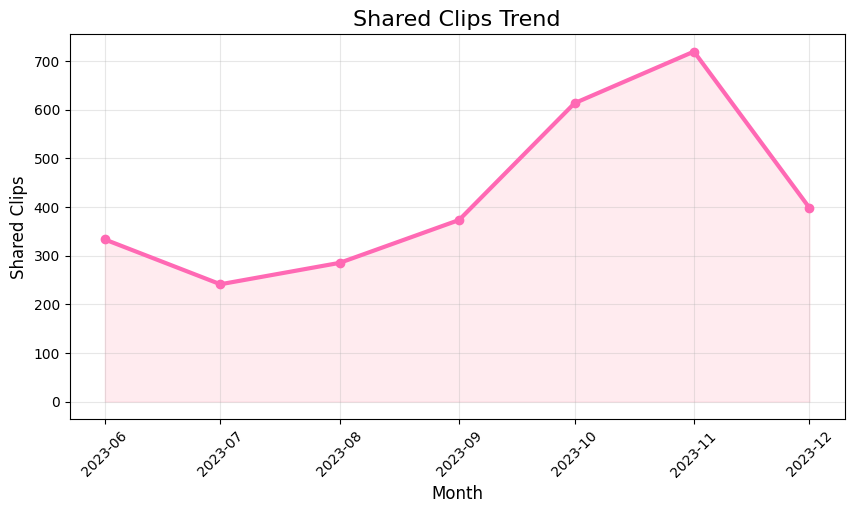

In [ ]:
result4['shared_month'] = pd.to_datetime(result4['shared_month'])

plt.figure(figsize=(10,5))

plt.plot(
    result4['shared_month'],
    result4['total_shared_clips'],
    marker='o',
    color=PINK,
    linewidth=3
)

plt.fill_between(
    result4['shared_month'],
    result4['total_shared_clips'],
    color=LIGHT_PINK,
    alpha=0.3
)

plt.title('Shared Clips Trend')
plt.xlabel('Month')
plt.ylabel('Shared Clips')

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## Insight  

Sharing activity accelerated significantly during Q4 2023.

This indicates:
- increasing creator willingness to distribute content externally
- stronger creator confidence in generated clips
- increasing social engagement behavior

# Strategic Implication

Because social sharing contributes to organic platform exposure, Eklipse should:
- improve social integrations
- simplify sharing workflows
- prioritize TikTok-focused features

Increasing creator distribution behavior
may help accelerate organic platform growth



---



# Monetization Expansion

## Business Objective

Measure premium subscription growth over time

## Why This Metric Matters

Premium adoption reflects:
- monetization performance
- creator willingness to pay
- perceived platform value

Increasing premium subscriptions indicate that creators are finding value in premium platform features

## SQL Strategy Used

This query uses INNER JOIN between:
- premium
- gamesession

The JOIN helps connect premium activity
with active creator behavior

DATE_TRUNC is used to evaluate monthly premium growth trends

In [ ]:
query5 = f'''
SELECT
    DATE_TRUNC('month', p.starts_at) AS premium_start_month,
    COUNT(DISTINCT p.user_id) AS new_premium_users
FROM '{BASE_PATH}/premium.csv' AS p
JOIN '{BASE_PATH}/gamesession.csv' AS gs
    ON p.user_id = gs.user_id
WHERE p.starts_at IS NOT NULL
GROUP BY premium_start_month
ORDER BY premium_start_month;
'''

result5 = con.execute(query5).df()

result5

,premium_start_month,new_premium_users
0,2023-01-01,9
1,2023-02-01,13
2,2023-03-01,22
3,2023-04-01,27
4,2023-05-01,26
5,2023-06-01,28
6,2023-07-01,30
7,2023-08-01,32
8,2023-09-01,40
9,2023-10-01,56


### monetization expansion visualization

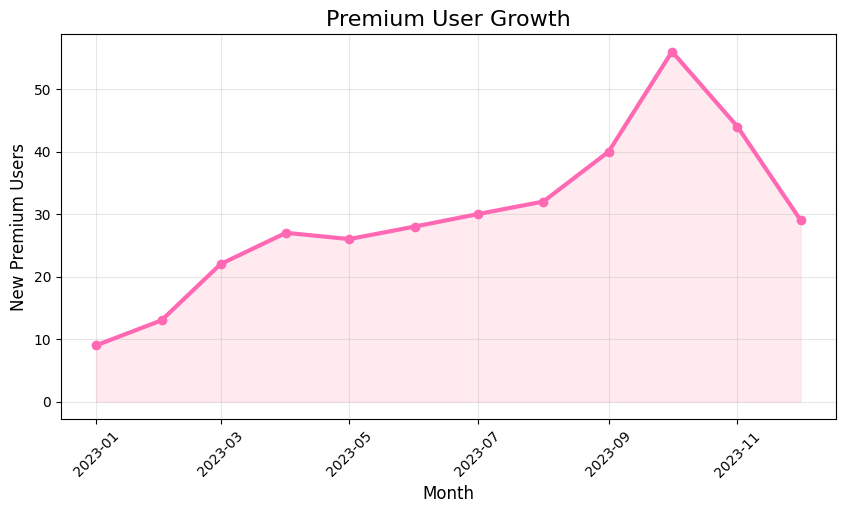

In [ ]:
result5['premium_start_month'] = pd.to_datetime(result5['premium_start_month'])

plt.figure(figsize=(10,5))

plt.plot(
    result5['premium_start_month'],
    result5['new_premium_users'],
    marker='o',
    color=PINK,
    linewidth=3
)

plt.fill_between(
    result5['premium_start_month'],
    result5['new_premium_users'],
    color=LIGHT_PINK,
    alpha=0.3
)

plt.title('Premium User Growth')
plt.xlabel('Month')
plt.ylabel('New Premium Users')

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

## Insight

Premium adoption increased consistently throughout 2023

The strongest growth appears during Q3–Q4 2023, which may indicate:
- increasing creator trust
- stronger perceived premium value
- improving monetization performance

# Strategic Implication

Because premium adoption continues increasing, Eklipse should:
- improve premium feature visibility
- target highly engaged creators
- strengthen premium differentiation

Premium monetization growth is likely connected to increasing creator engagement and content satisfaction



---



# Content Format Preferences

## Business Objective

Analyze the distribution of clip formats
generated across the platform

## Why This Metric Matters

This metric helps identify:
- creator content preferences
- dominant creator workflows
- product feature adoption

Understanding clip format usage helps Eklipse prioritize future product improvements

## SQL Strategy Used

This query uses:
- CASE WHEN
- GROUP BY
- COUNT DISTINCT

CASE WHEN is used to map clip_type_id values into human readable categories

GROUP BY aggregates clip counts for each content format

In [ ]:
query6 = f'''
SELECT
    CASE
        WHEN clip_type_id = 1 THEN 'AI Highlight'
        WHEN clip_type_id = 2 THEN 'TikTok Conversion'
        WHEN clip_type_id = 3 THEN 'Trimmed Clip'
        WHEN clip_type_id = 5 THEN 'Eventful Highlight'
        WHEN clip_type_id = 6 THEN 'Weekly Montage'
        WHEN clip_type_id = 7 THEN 'Local Upload'
        WHEN clip_type_id = 8 THEN 'YouTube Vertical'
        ELSE 'Unknown'
    END AS clip_type,

    COUNT(*) AS total_clips

FROM '{BASE_PATH}/clips.csv'

GROUP BY 1
ORDER BY total_clips DESC;
'''

result6 = con.execute(query6).df()

result6

,clip_type,total_clips
0,AI Highlight,513911
1,TikTok Conversion,20449
2,Eventful Highlight,11264
3,YouTube Vertical,5131
4,Trimmed Clip,1055
5,Weekly Montage,211
6,Local Upload,9
7,Unknown,1


### content format visualization

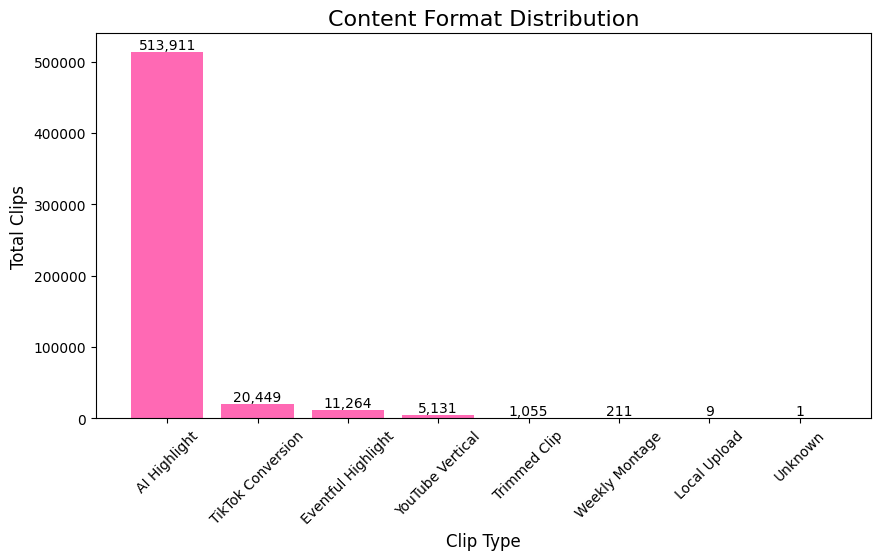

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    result6['clip_type'],
    result6['total_clips'],
    color=PINK
)

plt.title('Content Format Distribution')
plt.xlabel('Clip Type')
plt.ylabel('Total Clips')

plt.xticks(rotation=45)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.show()

## Insight

AI-generated clips dominate overall platform usage

This suggests:
- automated clipping is the platform’s primary value proposition
- creators rely heavily on AI-generated content
- creator workflows are centered around automation

TikTok conversion clips also show meaningful usage, indicating growing creator demand for short-form content workflows

# Strategic Implication

Because AI generated clips dominate platform activity, Eklipse should continue prioritizing:
- AI clipping quality
- processing accuracy
- creator personalization

The growing usage of TikTok conversion clips also suggests opportunities to expand shortform creator tools



---



# Strategic Implication

Because AI generated clips dominate platform activity, Eklipse should continue prioritizing:
- AI clipping quality
- processing accuracy
- creator personalization

The growing usage of TikTok conversion clips also suggests opportunities to expand short form creator tools

# Final Conclusion

The analysis indicates positive growth across creator engagement, content interaction, and monetization activity

Key conclusions:
- creator engagement increased consistently
- creator activity accelerated during Q3–Q4 2023
- download and sharing behavior improved steadily
- premium adoption continued growing
- AI-generated clips remain the platform’s strongest value proposition

Overall, the platform demonstrates strong creator ecosystem momentum,particularly within:
- AI generated content workflows
- creator distribution behavior
- premium feature adoption



---



# Final Strategic Recommendations

## 1. Improve Creator Onboarding

Increasing creator engagement suggests strong retention potential

Recommended actions:
- simplify creator onboarding
- improve workflow guidance
- highlight successful creator use cases

---

## 2. Strengthen Social Distribution Features

Sharing activity increased significantly during Q4 2023

Recommended actions:
- improve TikTok integration
- simplify clip distribution workflows
- prioritize creator sharing tools

---

## 3. Continue Optimizing AI Clip Quality

AI generated clips dominate platform usage

Recommended actions:
- improve clip accuracy
- optimize highlight timing
- personalize clip generation

---

## 4. Expand Premium Differentiation

Premium subscriptions continue increasing steadily

Recommended actions:
- expand premium exclusive features
- improve premium visibility
- target highly engaged creators

---

## 5. Increase Creator Retention Initiatives

The growth in monthly active users indicates strong creator retention potential

Recommended actions:
- creator milestone systems
- personalized recommendations
- retention focused notifications